# 01 — Geração AR/VAR estacionária por construção

## Resumo

Este notebook demonstra a implementação promovida para `src/tsfmxai/generators/stationary.py`. O gerador AR sorteia autocorrelações parciais estritamente dentro de $(-1,1)$ e as converte em coeficientes autorregressivos. O gerador VAR(1) sorteia uma matriz esparsa e a escala para um raio espectral inferior a um. Depois de certificar cada mecanismo, ambos resolvem a equação discreta de Lyapunov e sorteiam o estado inicial da distribuição Gaussiana estacionária. Assim, cada trajetória começa na distribuição invariante e preserva uma AST executável, os coeficientes, a lei da inovação e o certificado matemático.


## 1. Configuração reproduzível

Usamos sementes separadas para mecanismo e trajetórias. A implementação usa geradores NumPy locais e, portanto, não depende das sementes globais do programa que chama a biblioteca.


In [1]:
from __future__ import annotations

from pathlib import Path
import importlib.metadata
import json
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src' / 'tsfmxai').exists():
            return candidate
    raise RuntimeError('Repository root not found.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_ROOT = PROJECT_ROOT / 'src'
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from tsfmxai.generators import (
    StationaryARConfig,
    StationaryVAR1Config,
    ar_companion_matrix,
    sample_stationary_ar_mechanism,
    sample_stationary_ar_trajectories,
    sample_stationary_var1_mechanism,
    sample_stationary_var1_trajectories,
)

MECHANISM_SEED = 20261006
TRAJECTORY_SEED = 20261007
configuration = {
    'mechanism_seed': MECHANISM_SEED,
    'trajectory_seed': TRAJECTORY_SEED,
    'display_trajectories': 8,
    'display_steps': 160,
    'moment_check_trajectories': 4000,
    'moment_check_steps': 64,
    'python': platform.python_version(),
    'numpy': importlib.metadata.version('numpy'),
}
print(json.dumps(configuration, indent=2))

{
  "mechanism_seed": 20261006,
  "trajectory_seed": 20261007,
  "display_trajectories": 8,
  "display_steps": 160,
  "moment_check_trajectories": 4000,
  "moment_check_steps": 64,
  "python": "3.11.9",
  "numpy": "1.26.4"
}


**O que foi feito.** A célula localiza a biblioteca no repositório, importa somente a API pública e registra todas as sementes e tamanhos usados neste experimento.


## 2. Mecanismo AR($p$)

O mecanismo segue

$$X_t=c+\sum_{\ell=1}^{p}\phi_\ell X_{t-\ell}+\varepsilon_t,$$

com $c=\mu(1-\sum_\ell\phi_\ell)$. A parametrização por PACF garante que as raízes de $1-\sum_\ell\phi_\ell z^\ell$ fiquem fora do círculo unitário. O certificado armazena o menor módulo dessas raízes e sua distância até a fronteira um.


In [2]:
ar_config = StationaryARConfig(
    minimum_order=4,
    maximum_order=4,
    partial_autocorrelation_minimum=-0.70,
    partial_autocorrelation_maximum=0.70,
    mean_minimum=-0.5,
    mean_maximum=0.5,
    innovation_std_minimum=0.20,
    innovation_std_maximum=0.35,
)
ar_mechanism = sample_stationary_ar_mechanism(
    ar_config,
    seed=MECHANISM_SEED,
)
ar_transition = ar_companion_matrix(ar_mechanism.coefficients)
ar_covariance = np.asarray(ar_mechanism.stationary_state_covariance)
ar_noise = np.zeros_like(ar_transition)
ar_noise[0, 0] = ar_mechanism.innovation_std**2
ar_lyapunov_residual = np.linalg.norm(
    ar_covariance - ar_transition @ ar_covariance @ ar_transition.T - ar_noise,
    ord='fro',
)
display(pd.Series({
    'formula': ar_mechanism.formula,
    'partial_autocorrelations': np.round(ar_mechanism.partial_autocorrelations, 5).tolist(),
    'ar_coefficients': np.round(ar_mechanism.coefficients, 5).tolist(),
    'stationary_mean': ar_mechanism.stationary_mean,
    'innovation_std': ar_mechanism.innovation_std,
    'certificate_metric': ar_mechanism.certificate.metric_name,
    'certificate_value': ar_mechanism.certificate.metric_value,
    'certificate_margin': ar_mechanism.certificate.margin,
    'certificate_holds': ar_mechanism.certificate.holds,
    'lyapunov_residual': ar_lyapunov_residual,
}).to_frame('value'))
assert ar_mechanism.certificate.holds
assert ar_lyapunov_residual < 1e-10

,value
formula,x_0(t) = (((((x_0(t-1) * 0.984271) + 0.0146019...
partial_autocorrelations,"[0.43577, -0.2486, 0.69201, -0.38747]"
ar_coefficients,"[0.98427, -0.86735, 0.96949, -0.38747]"
stationary_mean,0.048503
innovation_std,0.231602
certificate_metric,minimum_lag_polynomial_root_modulus
certificate_value,1.083999
certificate_margin,0.083999
certificate_holds,True
lyapunov_residual,0.0


**O que foi feito.** Uma equação AR(4) foi sorteada, convertida para AST e certificada antes da simulação. O resíduo de Lyapunov verifica numericamente que a covariância armazenada é invariante sob um passo do mecanismo.


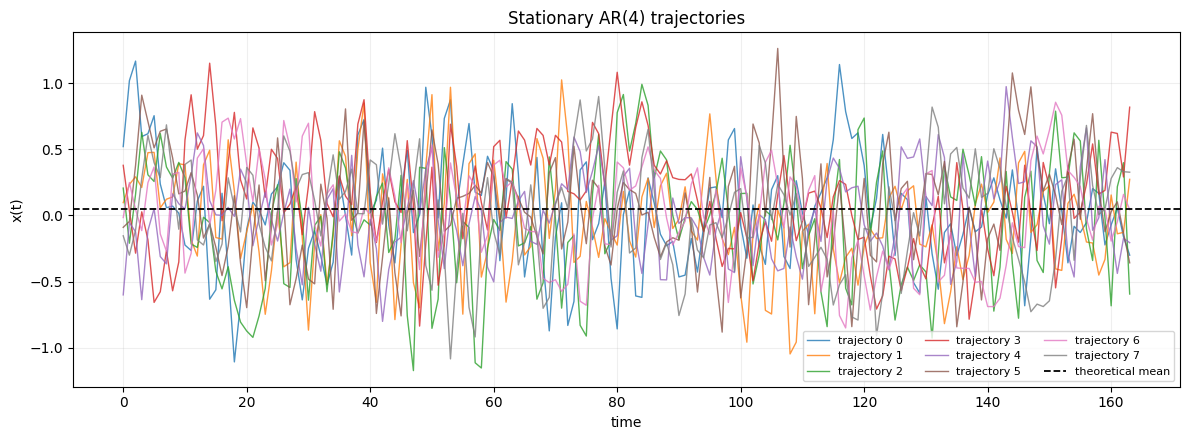

In [3]:
ar_display = sample_stationary_ar_trajectories(
    ar_mechanism,
    trajectory_count=configuration['display_trajectories'],
    generated_steps=configuration['display_steps'],
    root_seed=TRAJECTORY_SEED,
)
fig, ax = plt.subplots(figsize=(12, 4.5))
for index, trajectory in enumerate(ar_display):
    ax.plot(trajectory, linewidth=1.0, alpha=0.80, label=f'trajectory {index}')
ax.axhline(ar_mechanism.stationary_mean, color='black', linestyle='--', linewidth=1.3, label='theoretical mean')
ax.set(title='Stationary AR(4) trajectories', xlabel='time', ylabel='x(t)')
ax.legend(ncol=3, fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**O que foi feito.** Oito realizações independentes do mesmo mecanismo foram geradas. A região inicial não usa valores uniformes arbitrários: cada vetor de quatro valores passados foi sorteado da distribuição estacionária conjunta.


In [4]:
ar_ensemble = sample_stationary_ar_trajectories(
    ar_mechanism,
    trajectory_count=configuration['moment_check_trajectories'],
    generated_steps=configuration['moment_check_steps'],
    root_seed=TRAJECTORY_SEED + 1,
)
theoretical_ar_variance = ar_covariance[0, 0]
ar_moment_check = pd.DataFrame([
    {
        'position': 'initial observed value',
        'empirical_mean': ar_ensemble[:, 0].mean(),
        'empirical_variance': ar_ensemble[:, 0].var(),
        'theoretical_mean': ar_mechanism.stationary_mean,
        'theoretical_variance': theoretical_ar_variance,
    },
    {
        'position': 'last generated value',
        'empirical_mean': ar_ensemble[:, -1].mean(),
        'empirical_variance': ar_ensemble[:, -1].var(),
        'theoretical_mean': ar_mechanism.stationary_mean,
        'theoretical_variance': theoretical_ar_variance,
    },
])
display(ar_moment_check)

,position,empirical_mean,empirical_variance,theoretical_mean,theoretical_variance
0,initial observed value,0.040346,0.169040,0.048503,0.159353
1,last generated value,0.034651,0.154736,0.048503,0.159353


**O que foi feito.** Quatro mil trajetórias independentes permitem comparar momentos no primeiro e no último instante. Ambos permanecem próximos da média e variância teóricas, mostrando que nenhum período de aquecimento aparece na janela entregue ao usuário.


## 3. Mecanismo VAR(1) multivariado

O mecanismo bivariado segue

$$\mathbf{x}_t=(I-A)\boldsymbol\mu+A\mathbf{x}_{t-1}+\boldsymbol\varepsilon_t,\qquad \rho(A)<1.$$

A matriz inicialmente sorteada recebe zeros estruturais conforme `edge_probability` e é escalada para um raio espectral admissível. Cada linha de $A$ é convertida em uma equação AST para sua série-alvo.


In [5]:
var_config = StationaryVAR1Config(
    num_series=2,
    spectral_radius_minimum=0.45,
    spectral_radius_maximum=0.80,
    edge_probability=0.75,
    mean_minimum=-0.5,
    mean_maximum=0.5,
    innovation_std_minimum=0.15,
    innovation_std_maximum=0.30,
)
var_mechanism = sample_stationary_var1_mechanism(
    var_config,
    seed=MECHANISM_SEED + 1,
)
A = np.asarray(var_mechanism.coefficient_matrix)
D = np.asarray(var_mechanism.innovation_covariance)
C = np.asarray(var_mechanism.stationary_state_covariance)
var_lyapunov_residual = np.linalg.norm(C - A @ C @ A.T - D, ord='fro')
display(pd.Series({
    'equation_x0': var_mechanism.formulas[0],
    'equation_x1': var_mechanism.formulas[1],
    'coefficient_matrix': np.round(A, 5).tolist(),
    'stationary_mean': np.round(var_mechanism.stationary_mean, 5).tolist(),
    'spectral_radius': var_mechanism.certificate.metric_value,
    'certificate_margin': var_mechanism.certificate.margin,
    'certificate_holds': var_mechanism.certificate.holds,
    'lyapunov_residual': var_lyapunov_residual,
}).to_frame('value'))
assert var_mechanism.certificate.holds
assert var_lyapunov_residual < 1e-10

,value
equation_x0,x_0(t) = (((x_0(t-1) * -0.503382) + -0.792857)...
equation_x1,x_1(t) = ((x_0(t-1) * -0.0293189) + -0.341217)...
coefficient_matrix,"[[-0.50338, -0.56428], [-0.02932, -0.0]]"
stationary_mean,"[-0.40375, -0.32938]"
spectral_radius,0.534344
certificate_margin,0.465656
certificate_holds,True
lyapunov_residual,0.0


**O que foi feito.** O gerador retornou duas equações executáveis, a matriz $A$, a média, a covariância da inovação e a covariância estacionária. O raio espectral e o resíduo de Lyapunov são registrados como evidência do certificado.


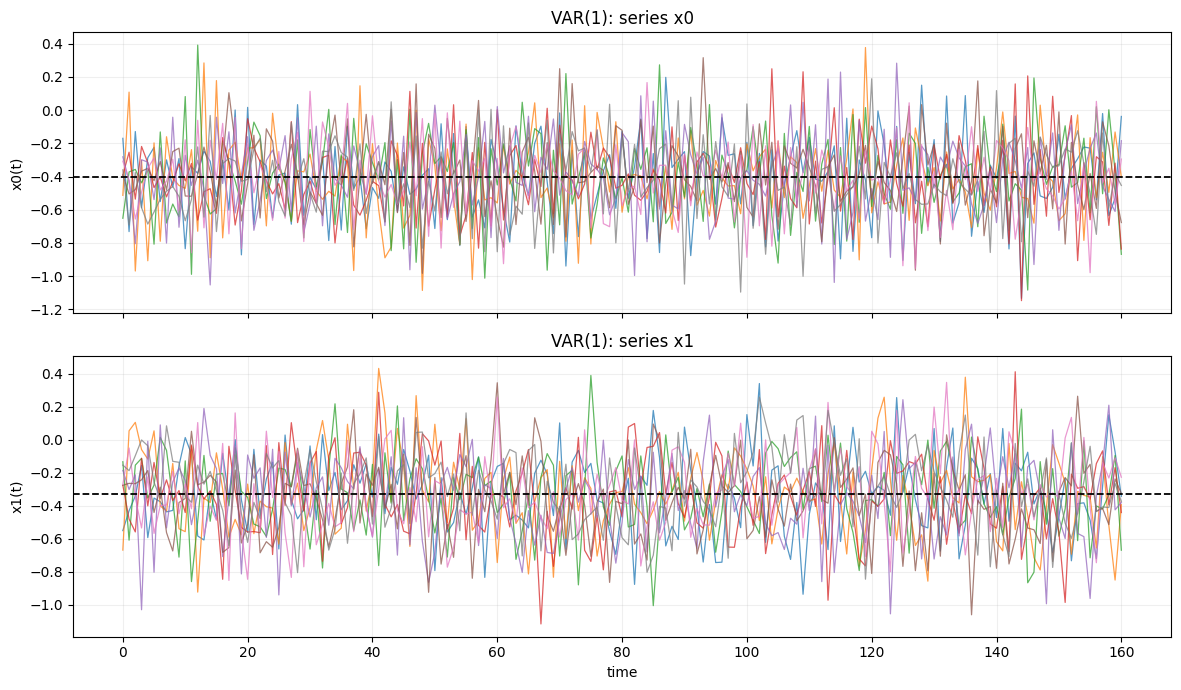

In [6]:
var_display = sample_stationary_var1_trajectories(
    var_mechanism,
    trajectory_count=configuration['display_trajectories'],
    generated_steps=configuration['display_steps'],
    root_seed=TRAJECTORY_SEED + 2,
)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for series_index, ax in enumerate(axes):
    for trajectory_index in range(var_display.shape[0]):
        ax.plot(var_display[trajectory_index, series_index], linewidth=0.9, alpha=0.75)
    ax.axhline(var_mechanism.stationary_mean[series_index], color='black', linestyle='--', linewidth=1.3)
    ax.set(ylabel=f'x{series_index}(t)', title=f'VAR(1): series x{series_index}')
    ax.grid(alpha=0.2)
axes[-1].set_xlabel('time')
plt.tight_layout()
plt.show()

**O que foi feito.** As duas séries de cada trajetória são geradas de forma síncrona com o mesmo mecanismo. Os painéis mostram todas as realizações e as médias teóricas, sem remover um trecho inicial.


In [7]:
var_ensemble = sample_stationary_var1_trajectories(
    var_mechanism,
    trajectory_count=configuration['moment_check_trajectories'],
    generated_steps=configuration['moment_check_steps'],
    root_seed=TRAJECTORY_SEED + 3,
)
var_moment_check = pd.DataFrame([
    {
        'position': 'initial state',
        'mean_error_L2': np.linalg.norm(var_ensemble[:, :, 0].mean(axis=0) - np.asarray(var_mechanism.stationary_mean)),
        'covariance_error_Frobenius': np.linalg.norm(np.cov(var_ensemble[:, :, 0], rowvar=False, bias=True) - C, ord='fro'),
    },
    {
        'position': 'last generated state',
        'mean_error_L2': np.linalg.norm(var_ensemble[:, :, -1].mean(axis=0) - np.asarray(var_mechanism.stationary_mean)),
        'covariance_error_Frobenius': np.linalg.norm(np.cov(var_ensemble[:, :, -1], rowvar=False, bias=True) - C, ord='fro'),
    },
])
display(var_moment_check)

,position,mean_error_L2,covariance_error_Frobenius
0,initial state,0.00449,0.004881
1,last generated state,0.00322,0.001276


**O que foi feito.** Os erros empíricos de média e covariância são calculados no estado inicial e após 64 passos. Sua mesma ordem de grandeza nos dois extremos é a evidência amostral complementar à garantia analítica.


## 4. Interface mínima da biblioteca

```python
from tsfmxai.generators import (
    StationaryARConfig,
    sample_stationary_ar_mechanism,
    sample_stationary_ar_trajectories,
)

mechanism = sample_stationary_ar_mechanism(
    StationaryARConfig(minimum_order=3, maximum_order=6),
    seed=7,
)
assert mechanism.certificate.holds

series = sample_stationary_ar_trajectories(
    mechanism,
    trajectory_count=128,
    generated_steps=512,
    root_seed=11,
)
```

O objeto `mechanism` retém a AST, fórmula, PACFs, coeficientes, média, distribuição da inovação, covariância inicial e certificado. `series` tem forma `[trajectory, time]`. Para VAR(1), a interface análoga retorna `[trajectory, series, time]`.


## 5. Resultado

A implementação adiciona uma alternativa ao filtro posterior de trajetórias explosivas. O mecanismo é aceito com base em sua região paramétrica, e o estado inicial é calculado a partir do mesmo mecanismo. Para o benchmark, a matriz de coeficientes fornece imediatamente o ground truth estrutural e assinado; potências da matriz companheira poderão propagar dependências para cada horizonte de previsão. A próxima extensão natural é a família não linear contrativa pesquisada no Notebook 00.


## Registro completo do experimento

- **Pergunta:** a API implementada produz mecanismos certificados e trajetórias que começam e permanecem na distribuição estacionária?
- **Hipótese:** PACF admissível e raio espectral inferior a um garantem os mecanismos; inicialização por Lyapunov mantém os momentos no início e no final.
- **Configuração:** AR(4) e VAR(1) bivariado; oito trajetórias visuais de 160 passos; 4.000 trajetórias de 64 passos para conferir momentos; sementes `20261006` e `20261007`.
- **Proveniência:** `src/tsfmxai/generators/stationary.py`; fundamentação no Notebook 00; commit-base `cda3a52af76e517bf2e5d9168adc33ee38904c57`, com alterações de trabalho ainda não commitadas.
- **Sementes:** geradores NumPy locais; sementes do mecanismo e das trajetórias são separadas; cada trajetória recebe subfluxos independentes para estado inicial e inovações.
- **Métricas:** margem do certificado, resíduo de Lyapunov, média e variância AR, erro vetorial da média VAR e erro de Frobenius da covariância VAR.
- **Resumo científico:** ambos os certificados foram satisfeitos; os resíduos de Lyapunov ficaram em precisão numérica; os momentos empíricos iniciais e finais permaneceram próximos dos momentos teóricos sem burn-in.
- **Artefatos:** somente este notebook executado; nenhum dataset ou sidecar foi criado.
- **Reprodução:** `.\.venv\Scripts\python.exe -m jupyter nbconvert --to notebook --execute --inplace experiments\abstract_syntax_tree\stationarity_by_construction\01_stationary_ar_var_generation.ipynb --ExecutePreprocessor.timeout=180`
